# 01_01 — Regresión PSBP sobre scores de FPCA (representación funcional)


# 1. Imports y rutas

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import time
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.models.psbp_fd_v2.psbp_fd_v2 import PSBP_FD_v2

# ── Módulos de visualización ──────────────────────────────────────────────────
# Apunta al paquete graphics/ que está dentro del proyecto
SYS_PATH_GRAPHICS = Path("graphics")
if str(SYS_PATH_GRAPHICS) not in sys.path:
    sys.path.insert(0, str(SYS_PATH_GRAPHICS))

from model_psbp_fd.graphics import (
    # viz_traces
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    # viz_global_components
    plot_global_components, plot_active_clusters,
    # viz_functional_data
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    # viz_time_series
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    # viz_prediction
    plot_scatter_theta, plot_functional_comparison,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [34]:
# ── Raíz del proyecto ─────────────────────────────────────────────────────────
def get_project_root(marker: str = "README.md") -> Path:
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current

PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

# ── Identificación del experimento ────────────────────────────────────────────
# Debe definirse ANTES de PATHS porque la carpeta de salida lleva el ID.
BASENAME      = "FAR_lineal_st_nuevo_modelo"
TT            = 2
SEED          = 4123
#TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"01_01_modelo_{TT}"#_{TIMESTAMP}"
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

# ── Rutas canónicas ───────────────────────────────────────────────────────────
_REPORT_DIR = PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,                         # Datos: raw + estandarizados
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,    # Coeficientes funcionales + FPCA
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,       # Datos predichos
    "out_report":   _REPORT_DIR,          # Figuras + métricas/config JSON
    "out_artefact": _ARTEFACT_DIR,        # Artefactos (serializados, por experimento)
    "out":          _REPORT_DIR,          # alias retrocompatible (= out_report): destino de PATHS["out"]
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

PROJECT_ROOT : C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
Experiment ID : 01_01_modelo_2
Seed (base)   : 4123
  raw        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw\01_01_modelo_2
  functional → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\functional\01_01_modelo_2
  predict    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\predict\01_01_modelo_2
  out_report → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones\01_01_modelo_2
  out_artefact → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\artefact\simulaciones\01_01_modelo_2
  out        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones\01_01_modelo_2


# 2. Simulación y estandarización

## 2.1 Parámetros e identificación del experimento

In [35]:
FAR_PARAMS = {
    "n_curves":       100,
    "n_points":       100,
    "bandwidth":      0.05,
    "decay":          0.8,
    "temporal_slope": 4.0,
    "spatial_slope":  2.0,
    "intercept":      1.0,
    "noise_std":      0.2,
    "noise_type":     "smooth",
    "burn_in":        100,
}
for k, v in FAR_PARAMS.items():
    print(f"  {k:<18}: {v}")

  n_curves          : 100
  n_points          : 100
  bandwidth         : 0.05
  decay             : 0.8
  temporal_slope    : 4.0
  spatial_slope     : 2.0
  intercept         : 1.0
  noise_std         : 0.2
  noise_type        : smooth
  burn_in           : 100


## 2.2 Simulación FAR(1)

In [36]:
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])
Psi    = build_integral_matrix(
    domain, gaussian_integral_kernel,
    bandwidth=FAR_PARAMS["bandwidth"],
    decay=FAR_PARAMS["decay"],
)

sim = FARSimulator(
    domain=domain,
    n_curves=FAR_PARAMS["n_curves"],
    Psi=Psi,
    trend="linear",
    trend_params={
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std=FAR_PARAMS["noise_std"],
    noise_type=FAR_PARAMS["noise_type"],
    burn_in=FAR_PARAMS["burn_in"],
    random_state=SEED,
)
X_raw = sim.simulate()   # (T, G)
T, G  = X_raw.shape
print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")

Datos simulados : (100, 100)  →  T=100 curvas, G=100 puntos


## 2.3 Visualización de los datos empíricos

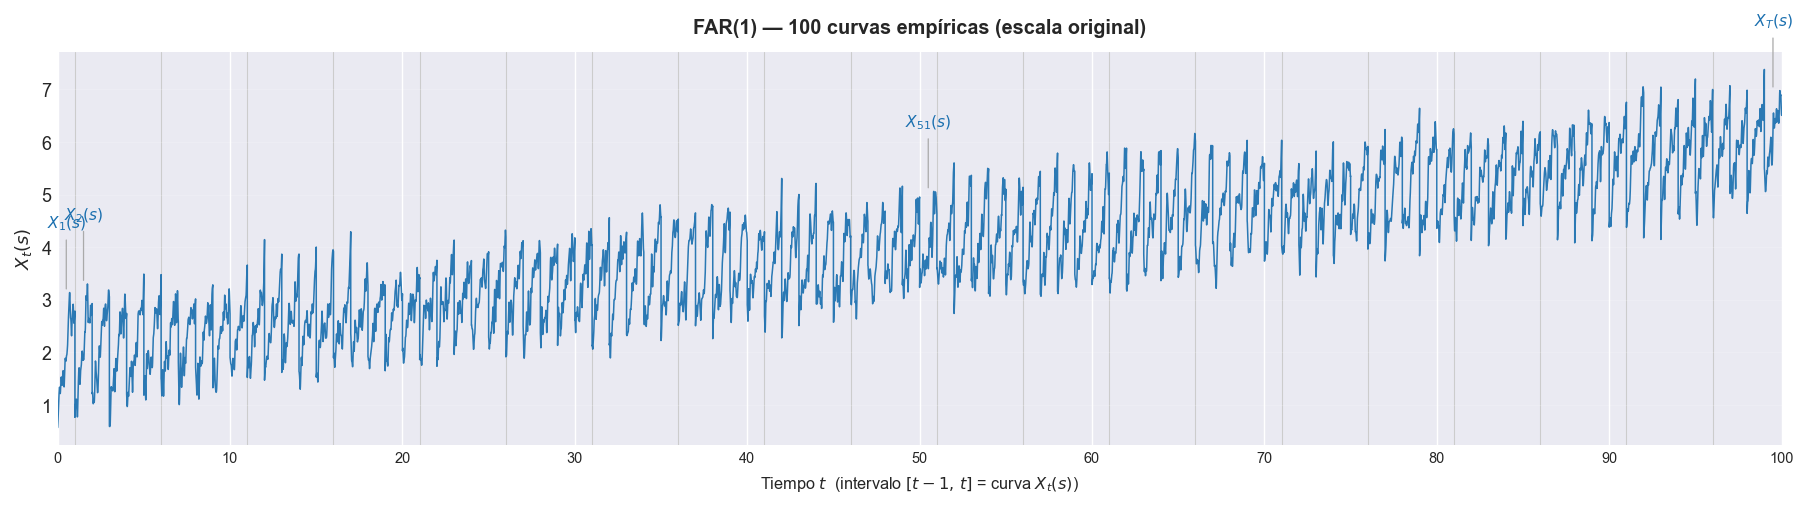

In [37]:
# ── Serie de tiempo funcional empírica (línea continua desplazada) ────────────
highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out"] / "01_fts_empirica_raw.png"),
)
plt.show()

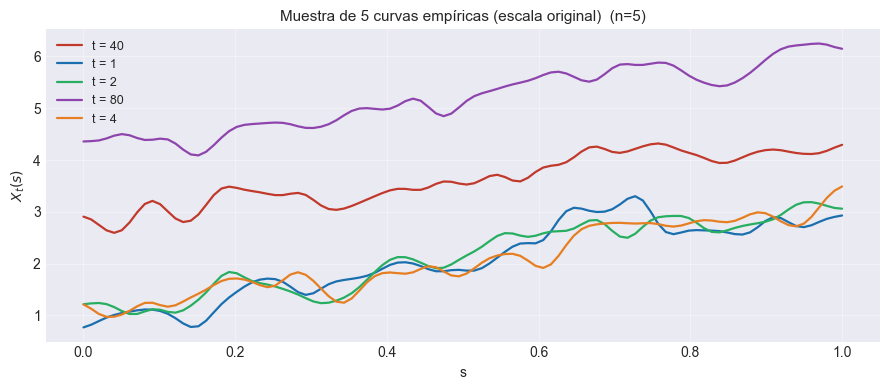

In [38]:
# ── Muestra de curvas empíricas (5 índices fijos) ─────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [40, 1, 2, 80, 4],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out"] / "02_muestra_empirica_raw.png"),
)
plt.show()

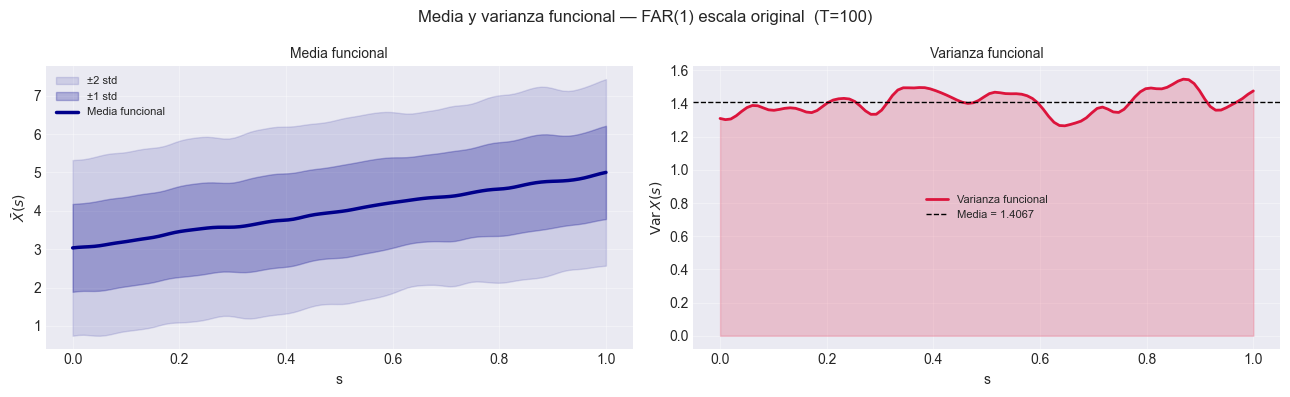

In [39]:
# ── Media y varianza funcional (panel combinado) ──────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — FAR(1) escala original",
    save_path = str(PATHS["out"] / "03_media_varianza_raw.png"),
)
plt.show()

## 2.4 Estandarización por columna (z-score)

In [40]:
STANDARIZE_CONFIG = {"method": "zscore_column", "ddof": 0, "store_stats": True}

X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0, ddof=STANDARIZE_CONFIG["ddof"])

if np.any(X_std == 0):
    raise ValueError(f"Columnas con varianza nula: {np.where(X_std == 0)[0].tolist()}")

X = (X_raw - X_mean) / X_std
print(f"X estandarizada : shape={X.shape}")
print(f"  max|media|  = {np.abs(X.mean(axis=0)).max():.2e}  (debe ≈ 0)")
print(f"  max|std-1|  = {np.abs(X.std(axis=0) - 1).max():.2e}  (debe ≈ 0)")

# ── Persistencia de datos · etapa raw/estandarizada → data/.../raw ───────────
np.savetxt(PATHS["raw"] / "datos_raw.csv",       X_raw, delimiter=",")
np.savetxt(PATHS["raw"] / "datos_transform.csv", X,     delimiter=",")
np.savez(PATHS["raw"] / "standardization.npz", mean=X_mean, std=X_std,
         ddof=STANDARIZE_CONFIG["ddof"])
print(f"[raw] datos_raw {X_raw.shape} · datos_transform {X.shape} · standardization.npz  →  {PATHS['raw']}")

X estandarizada : shape=(100, 100)
  max|media|  = 2.64e-15  (debe ≈ 0)
  max|std-1|  = 4.44e-16  (debe ≈ 0)
[raw] datos_raw (100, 100) · datos_transform (100, 100) · standardization.npz  →  C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw\01_01_modelo_2


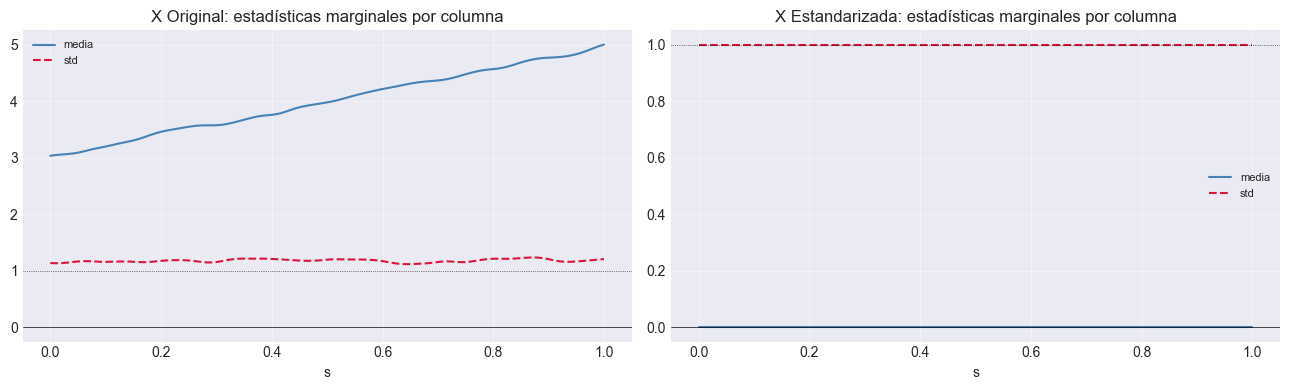

In [41]:
# ── Diagnóstico visual de estandarización ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, Xp, lbl in zip(axes, [X_raw, X], ["Original", "Estandarizada"]):
    ax.plot(domain.grid, Xp.mean(axis=0), color="steelblue", lw=1.5, label="media")
    ax.plot(domain.grid, Xp.std(axis=0),  color="crimson",   lw=1.5, ls="--", label="std")
    ax.axhline(0, color="k", lw=0.5)
    ax.axhline(1, color="k", lw=0.5, ls=":")
    ax.set_title(f"X {lbl}: estadísticas marginales por columna")
    ax.set_xlabel("s"); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(PATHS["out"] / "04_diagnostico_estandarizacion.png", dpi=130, bbox_inches="tight")
plt.show()

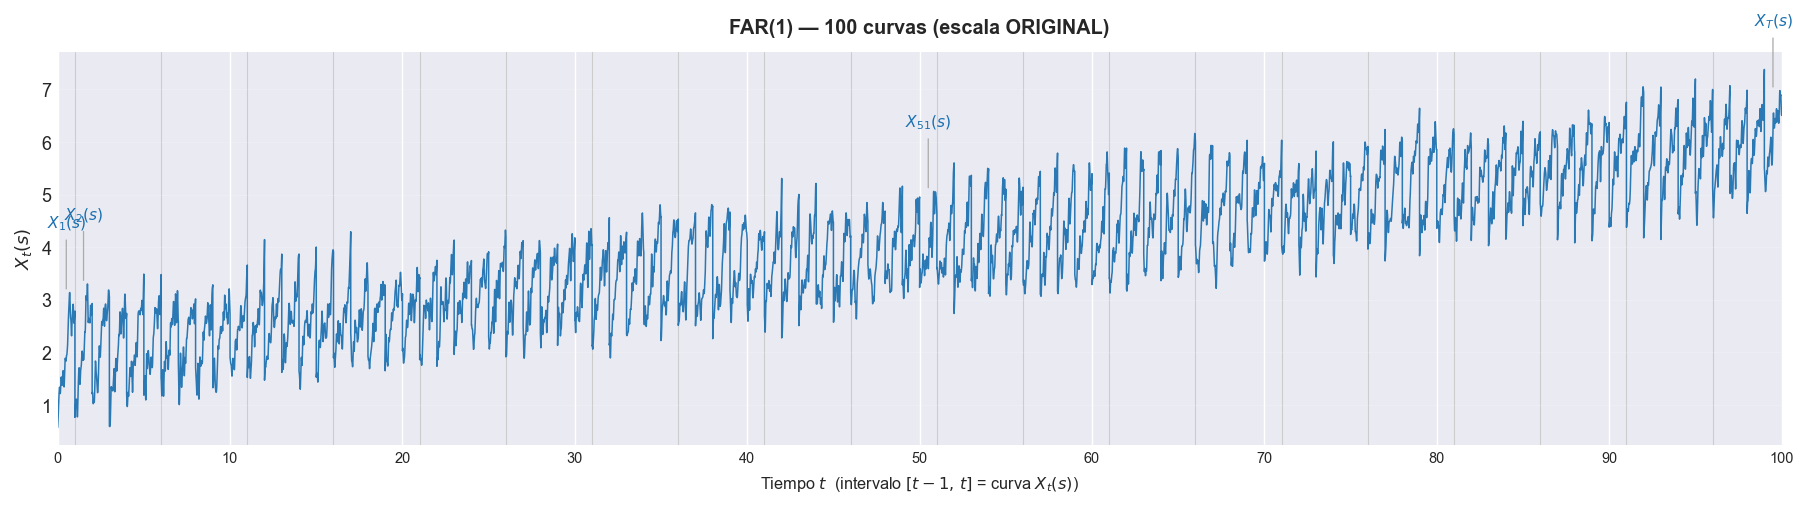

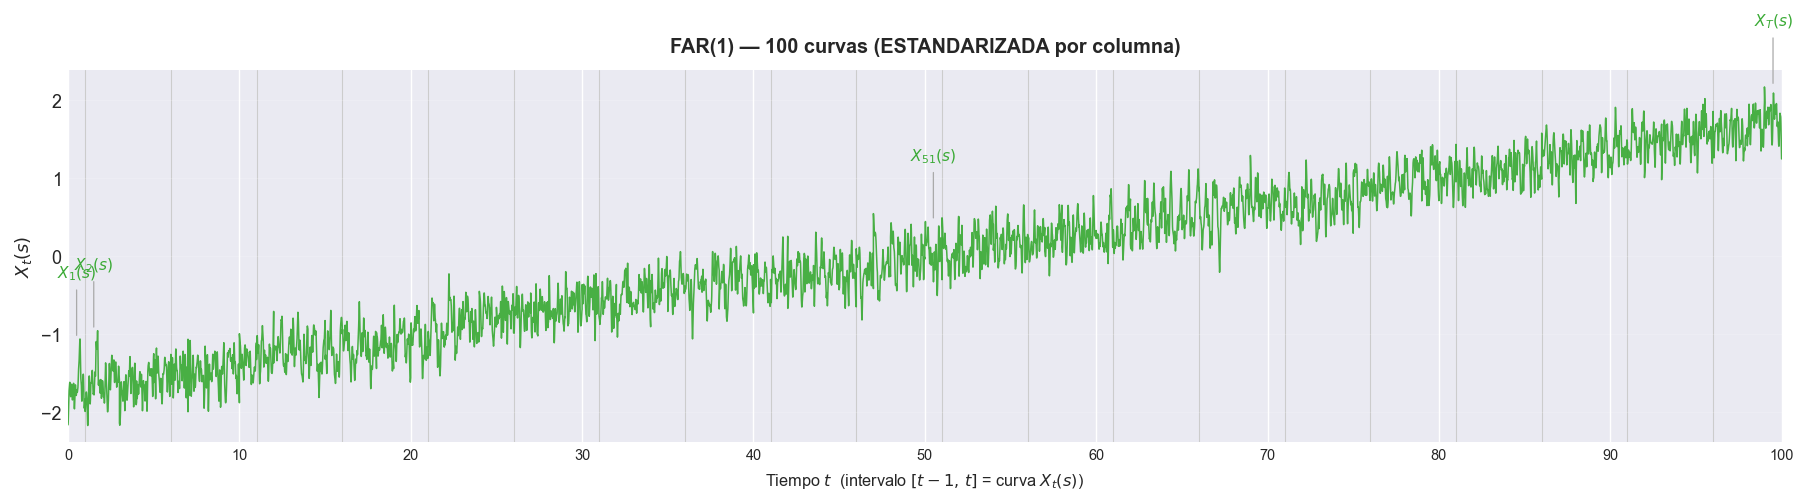

In [42]:
# ── Series de tiempo funcionales: original vs estandarizada ──────────────────
fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx=highlight_idx,
    title=f"FAR(1) — {T} curvas (escala ORIGINAL)",
    separator_every=5,
    save_path=str(PATHS["out"] / "05_fts_empirica_original.png"),
)
plt.show()

fig = plot_fts_empirical(
    X, domain.grid,
    highlight_idx=highlight_idx,
    color="#3aaa35",
    title=f"FAR(1) — {T} curvas (ESTANDARIZADA por columna)",
    separator_every=5,
    save_path=str(PATHS["out"] / "06_fts_empirica_std.png"),
)
plt.show()

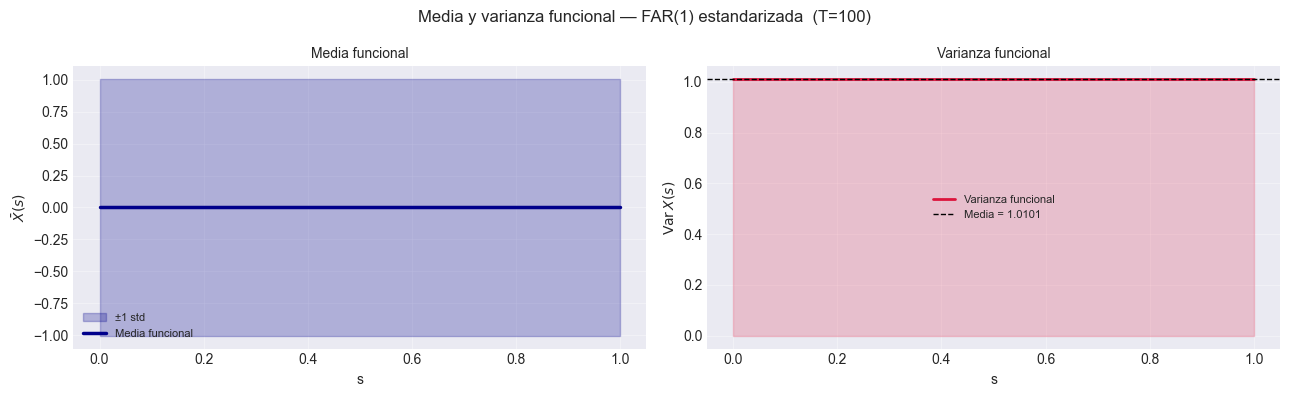

In [43]:
# ── Media y varianza funcional de X estandarizada ────────────────────────────
fig = plot_mean_and_variance(
    X, domain.grid,
    show_std1 = True,
    title     = "Media y varianza funcional — FAR(1) estandarizada",
    save_path = str(PATHS["out"] / "07_media_varianza_std.png"),
)
plt.show()

# 3. Representación funcional B-spline

## 3.1 Selección de n_basis × order

In [44]:
N_BASIS_RANGE = range(2, min(20, T // 2))
ORDER_RANGE   = range(1, 5)
selection_records = []

for order in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order)
            TH_tmp = fr_tmp.fit_transform(X, domain.grid)
            X_rec  = fr_tmp.reconstruct(TH_tmp)
            ss_res = np.sum((X - X_rec) ** 2)
            ss_tot = np.sum((X - X.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - ss_res / ss_tot
            rmse_c = np.sqrt(np.mean((X - X_rec) ** 2, axis=1))
            selection_records.append({
                "n_basis": nb, "order": order, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order}: {e}")

sel_df   = pd.DataFrame(selection_records)
best_idx = sel_df.sort_values(["var_retained", "n_basis"], ascending=[False, True]).index[0]
best_row = sel_df.loc[best_idx]
nb_best  = int(best_row["n_basis"])
ord_best = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}", "rmse_max": "{:.6f}"})
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))
print(f"\nRecomendación: n_basis={nb_best}, order={ord_best}, var_retained={best_row['var_retained']:.4%}")

,n_basis,order,var_retained,rmse_mean,rmse_max
0,2,1,96.5493%,0.183878,0.253993
1,3,1,96.8795%,0.174338,0.244964
2,4,1,97.4608%,0.157998,0.218081
3,5,1,97.6320%,0.152535,0.209721
4,6,1,97.7929%,0.146969,0.195886
5,7,1,97.9645%,0.141471,0.178270
6,8,1,98.2622%,0.130595,0.180333
7,9,1,98.3934%,0.125417,0.170850
8,10,1,98.4936%,0.121672,0.155137
9,11,1,98.6555%,0.114465,0.162740



Recomendación: n_basis=19, order=3, var_retained=99.6489%


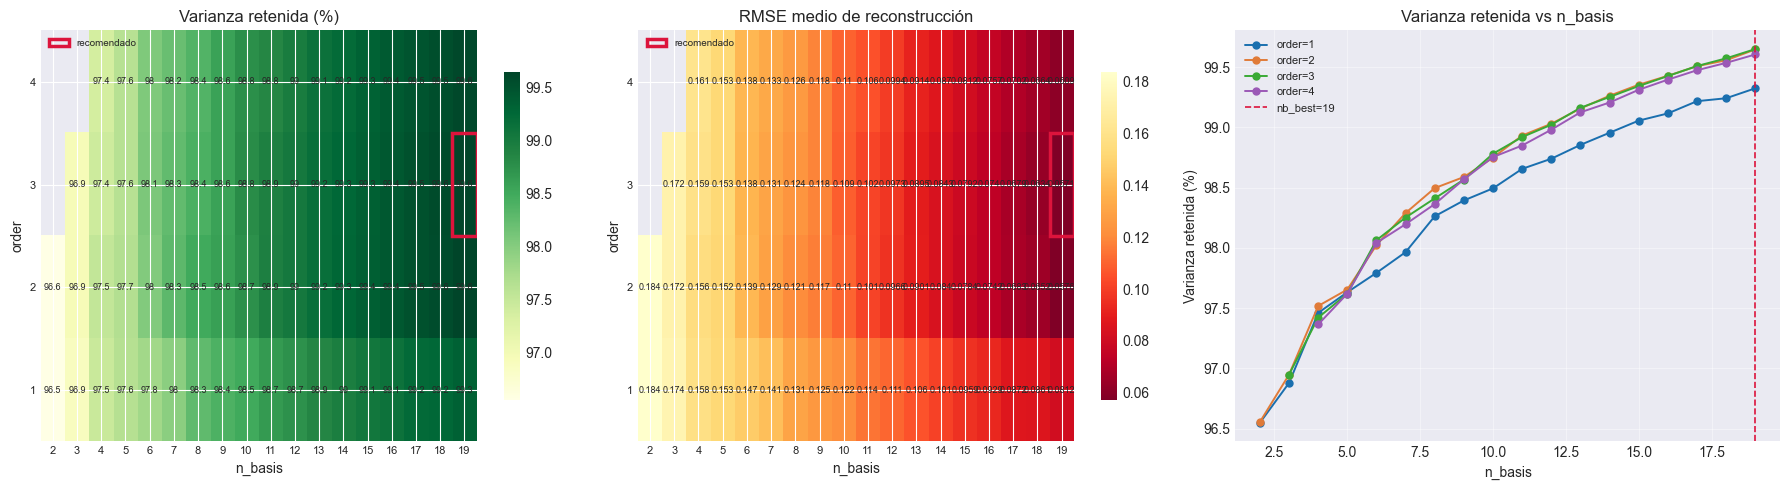

In [45]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
vr_pivot   = sel_df.pivot(index="order", columns="n_basis", values="var_retained")
rmse_pivot = sel_df.pivot(index="order", columns="n_basis", values="rmse_mean")
best_nb_idx  = list(vr_pivot.columns).index(nb_best)
best_ord_idx = list(vr_pivot.index).index(ord_best)
orders_list  = sorted(sel_df["order"].unique())
colors_ord   = ["#1a6faf", "#e07b39", "#3aaa35", "#9b59b6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pivot, cmap, label in [
    (axes[0], vr_pivot*100,   "YlGn",    "Varianza retenida (%)"),
    (axes[1], rmse_pivot,     "YlOrRd_r", "RMSE medio de reconstrucción"),
]:
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, origin="lower")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index,   fontsize=8)
    ax.set_xlabel("n_basis"); ax.set_ylabel("order"); ax.set_title(label)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3g}", ha="center", va="center", fontsize=6.5)
    ax.add_patch(plt.Rectangle(
        (best_nb_idx-.5, best_ord_idx-.5), 1, 1,
        fill=False, edgecolor="crimson", lw=2.5, label="recomendado"))
    ax.legend(fontsize=7, loc="upper left")
    plt.colorbar(im, ax=ax, shrink=0.8)

for i, ord_ in enumerate(orders_list):
    sub = sel_df[sel_df["order"] == ord_].sort_values("n_basis")
    axes[2].plot(sub["n_basis"], sub["var_retained"]*100, marker="o", lw=1.4, ms=5,
                 color=colors_ord[i % 4], label=f"order={ord_}")
axes[2].axvline(nb_best, color="crimson", ls="--", lw=1.2, label=f"nb_best={nb_best}")
axes[2].set_xlabel("n_basis"); axes[2].set_ylabel("Varianza retenida (%)")
axes[2].set_title("Varianza retenida vs n_basis"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(PATHS["out"] / "08_seleccion_basis.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.2 Ajuste y visualización de la representación funcional

THETA shape: (100, 10)  (T=100, K=10)


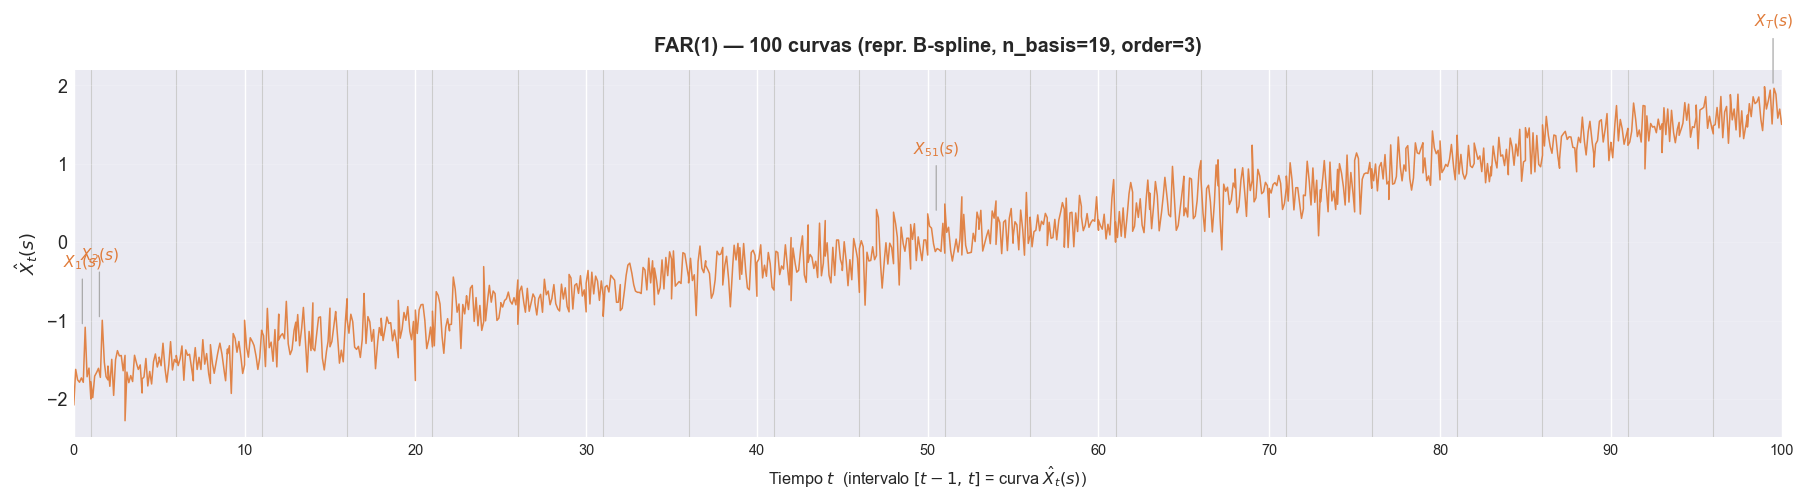

In [46]:
#CONSTANTES 
fr    = FunctionalRepresentation(method="bspline", n_basis=10, order=2)

# Ajuste
THETA = fr.fit_transform(X, domain.grid)
print(f"THETA shape: {THETA.shape}  (T={THETA.shape[0]}, K={THETA.shape[1]})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas (repr. B-spline, n_basis={nb_best}, order={ord_best})",
    separator_every = 5,
    save_path       = str(PATHS["out"] / "09_fts_funcional_bspline.png"),
)
plt.show()

## 3.3 Pasar la base selecionada a FPCA analizar cuantos componentes me quedare

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,9.7137e-01,97.3715%,97.3715%,+1.000
1,2,6.6033e-03,0.6619%,98.0334%,+0.838
2,3,5.3623e-03,0.5375%,98.5709%,+0.743
3,4,3.7049e-03,0.3714%,98.9423%,+0.591
4,5,2.6717e-03,0.2678%,99.2101%,+0.606
5,6,2.1859e-03,0.2191%,99.4292%,+0.402
6,7,1.8549e-03,0.1859%,99.6152%,+0.253
7,8,1.7581e-03,0.1762%,99.7914%,+0.363
8,9,1.1037e-03,0.1106%,99.9020%,+0.037
9,10,9.7733e-04,0.0980%,100.0000%,-0.067



K B-spline disponibles : 10
SUGERENCIA (var ≥ 99%) : M_SUGGERIDO = 5   ← solo referencia; fija M_FPCA en la celda 3.4


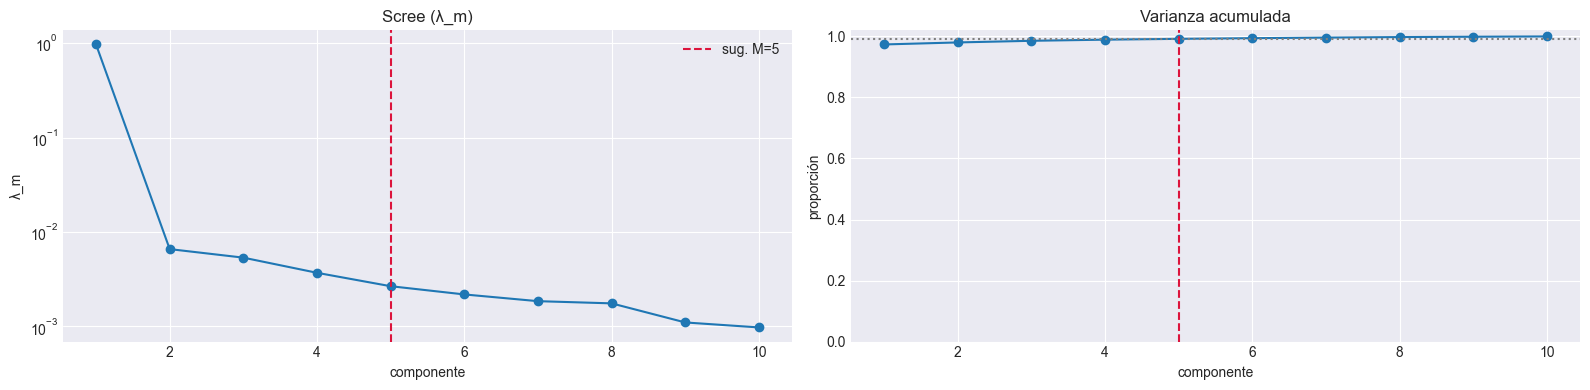

In [47]:
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I. La FPCA correcta
# diagonaliza en métrica L²:  (W^{1/2} S_θ W^{1/2}) u = λ u,  ‖ψ_m‖_{L²}=1.
# ----------------------------------------------------------------------------
K = THETA.shape[1]

# ── Base en grilla + verificación de linealidad de reconstruct ───────────────
Phi = fr.reconstruct(np.eye(K)).T                        # (G, K): columna k = φ_k en grilla
_lin_err = np.abs(fr.reconstruct(THETA) - THETA @ Phi.T).max()
assert _lin_err < 1e-8, (
    f"reconstruct no es el mapa lineal Θ·Φᵀ esperado (err={_lin_err:.2e})."
)

# ── Gram L² (cuadratura trapezoidal) ─────────────────────────────────────────
gpts = np.asarray(domain.grid, dtype=float)
w_quad = np.empty_like(gpts)
w_quad[1:-1] = (gpts[2:] - gpts[:-2]) / 2.0
w_quad[0]    = (gpts[1]  - gpts[0])  / 2.0
w_quad[-1]   = (gpts[-1] - gpts[-2]) / 2.0
W = Phi.T @ (w_quad[:, None] * Phi); W = 0.5 * (W + W.T)

# ── Covarianza de coeficientes y problema propio simetrizado en L² ───────────
mu_theta = THETA.mean(axis=0)
Theta_c  = THETA - mu_theta
S_theta  = (Theta_c.T @ Theta_c) / (THETA.shape[0] - 1)
evW, VW    = np.linalg.eigh(W); evW = np.clip(evW, 1e-12, None)
W_half     = VW @ np.diag(np.sqrt(evW))   @ VW.T
W_half_inv = VW @ np.diag(1 / np.sqrt(evW)) @ VW.T
M_sym = W_half @ S_theta @ W_half; M_sym = 0.5 * (M_sym + M_sym.T)
evals, U = np.linalg.eigh(M_sym)
order = np.argsort(evals)[::-1]
evals = np.clip(evals[order], 0.0, None); U = U[:, order]
B_full = W_half_inv @ U                                  # (K, K) coef. autofunciones (b_mᵀ W b_m = 1)
var_ratio = evals / evals.sum(); var_cum = np.cumsum(var_ratio)

# ── Diagnóstico DINÁMICO: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de var. baja puede tener
# AR fuerte (útil para pronóstico) y una de var. alta puede ser ruido temporal.
SCORES_full = Theta_c @ (W @ B_full)                     # (T, K) scores de TODAS las componentes
s0, s1 = SCORES_full[:-1], SCORES_full[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)   # pendiente AR(1) por comp.

# ── Sugerencia automática (SOLO referencia; no vincula nada) ─────────────────
VAR_TARGET  = 0.99
M_SUGGERIDO = int(np.clip(np.searchsorted(var_cum, VAR_TARGET) + 1, 1, K))

# ── Tabla ─────────────────────────────────────────────────────────────────────
fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"}
).background_gradient(subset=["var_ratio"], cmap="YlGn")
 .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda 3.4")

# ── Scree + varianza acumulada + AR(1) por componente ────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].plot(np.arange(1, K + 1), evals, "o-")
ax[0].axvline(M_SUGGERIDO, ls="--", c="crimson", label=f"sug. M={M_SUGGERIDO}")
ax[0].set(title="Scree (λ_m)", xlabel="componente", ylabel="λ_m"); ax[0].set_yscale("log"); ax[0].legend()
ax[1].plot(np.arange(1, K + 1), var_cum, "o-")
ax[1].axhline(VAR_TARGET, ls=":", c="grey"); ax[1].axvline(M_SUGGERIDO, ls="--", c="crimson")
ax[1].set(title="Varianza acumulada", xlabel="componente", ylabel="proporción", ylim=(0, 1.02))
fig.tight_layout()
fig.savefig(PATHS["out"] / "10_fpca_scree.png", dpi=110, bbox_inches="tight")
plt.show()

## 3.4 Obtener el FPCA basado en la selecion

[sanidad] max|<ψ_i,ψ_j> - I| : 1.33e-15   (≈ 0)
max|media ξ|                 : 2.24e-16   (≈ 0)
max|diag(Γ0) - λ|            : 4.44e-16   (≈ 0)
max|correlación fuera diag.| : 8.09e-15   (≈ 0 ⇒ sin correlación contemporánea)


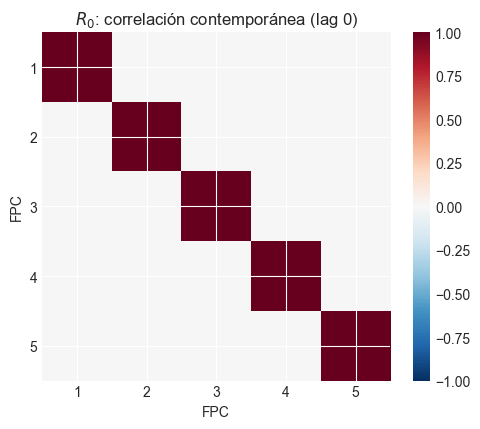


SCORES shape : (100, 5)   (T=100, M=5)


In [48]:
M_FPCA = 5    # ← nº de componentes FPCA a retener (lo fijas TÚ)

# ── Validación (no avanza hasta que elijas) ──────────────────────────────────
assert M_FPCA is not None, "Define M_FPCA (entero) en esta celda antes de continuar."
assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= K, (
    f"M_FPCA debe ser entero en [1, {K}]. Recibido: {M_FPCA!r}"
)
M_fpca = int(M_FPCA)                                     # alias en minúscula para el resto del notebook

# ── Construcción con el M elegido ────────────────────────────────────────────
B        = B_full[:, :M_fpca]                            # (K, M)
Psi_grid = Phi @ B                                       # (G, M) autofunciones (‖ψ_m‖_{L²}=1)
mu_grid  = Phi @ mu_theta                                # (G,)
SCORES   = Theta_c @ (W @ B)                             # (T, M) scores ξ

# ── Sanidad de construcción: autofunciones ortonormales en L² (Gram ≈ I) ─────
gram_psi = Psi_grid.T @ (w_quad[:, None] * Psi_grid)
print(f"[sanidad] max|<ψ_i,ψ_j> - I| : {np.abs(gram_psi - np.eye(M_fpca)).max():.2e}   (≈ 0)")

# EVALUACIÓN DE CORRELACIÓN  (lag 0)
Gamma0 = np.atleast_2d(np.cov(SCORES, rowvar=False, ddof=1))     # covarianza lag 0
R0     = np.atleast_2d(np.corrcoef(SCORES, rowvar=False))        # correlación lag 0
off_R0 = np.abs(R0 - np.eye(M_fpca))

print(f"max|media ξ|                 : {np.abs(SCORES.mean(0)).max():.2e}   (≈ 0)")
print(f"max|diag(Γ0) - λ|            : {np.abs(np.diag(Gamma0) - evals[:M_fpca]).max():.2e}   (≈ 0)")
print(f"max|correlación fuera diag.| : {off_R0.max():.2e}   (≈ 0 ⇒ sin correlación contemporánea)")

if M_fpca >= 2:
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    im = ax.imshow(R0, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(r"$R_0$: correlación contemporánea (lag 0)")
    ax.set_xlabel("FPC"); ax.set_ylabel("FPC")
    ax.set_xticks(range(M_fpca)); ax.set_yticks(range(M_fpca))
    ax.set_xticklabels(range(1, M_fpca + 1)); ax.set_yticklabels(range(1, M_fpca + 1))
    plt.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    fig.savefig(PATHS["out"] / "11_fpca_correlacion_lag0.png", dpi=110, bbox_inches="tight")
    plt.show()

# ── Empaquetado FPCA + operador de reconstrucción (inversa de FPCA) ──────────
def reconstruct_from_scores(S_hat):
    """X̂(t) = μ(t) + Σ_m ξ_m ψ_m(t)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return mu_grid[None, :] + S_hat @ Psi_grid.T

FPCA = {
    "M": M_fpca, "eigvals": evals[:M_fpca], "mean_grid": mu_grid,
    "eigfun_grid": Psi_grid, "coef_eigfun": B, "gram": W,
    "reconstruct": reconstruct_from_scores,
}

# ── Persistencia de datos · representación funcional + FPCA → data/.../functional ──
np.savetxt(PATHS["functional"] / "theta.csv",               THETA,    delimiter=",")
np.savetxt(PATHS["functional"] / "basis_phi.csv",           Phi,      delimiter=",")
np.savetxt(PATHS["functional"] / "grid.csv",                gpts,     delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_scores.csv",         SCORES,   delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_eigenfunctions.csv", Psi_grid, delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mean.csv",           mu_grid,  delimiter=",")
with open(PATHS["functional"] / "fpca_meta.json", "w", encoding="utf-8") as _f:
    json.dump({"M": int(M_fpca), "K": int(THETA.shape[1]),
               "eigvals": FPCA["eigvals"].tolist(),
               "var_explained": float(var_cum[M_fpca - 1]), "var_target": VAR_TARGET},
              _f, indent=2, ensure_ascii=False)

print(f"\nSCORES shape : {SCORES.shape}   (T={SCORES.shape[0]}, M={M_fpca})")

# 4. Construcción de datasets AR(p) sobre scores de FPCA (ecuación-por-ecuación)

## 4.1 Analisis de rezasgos

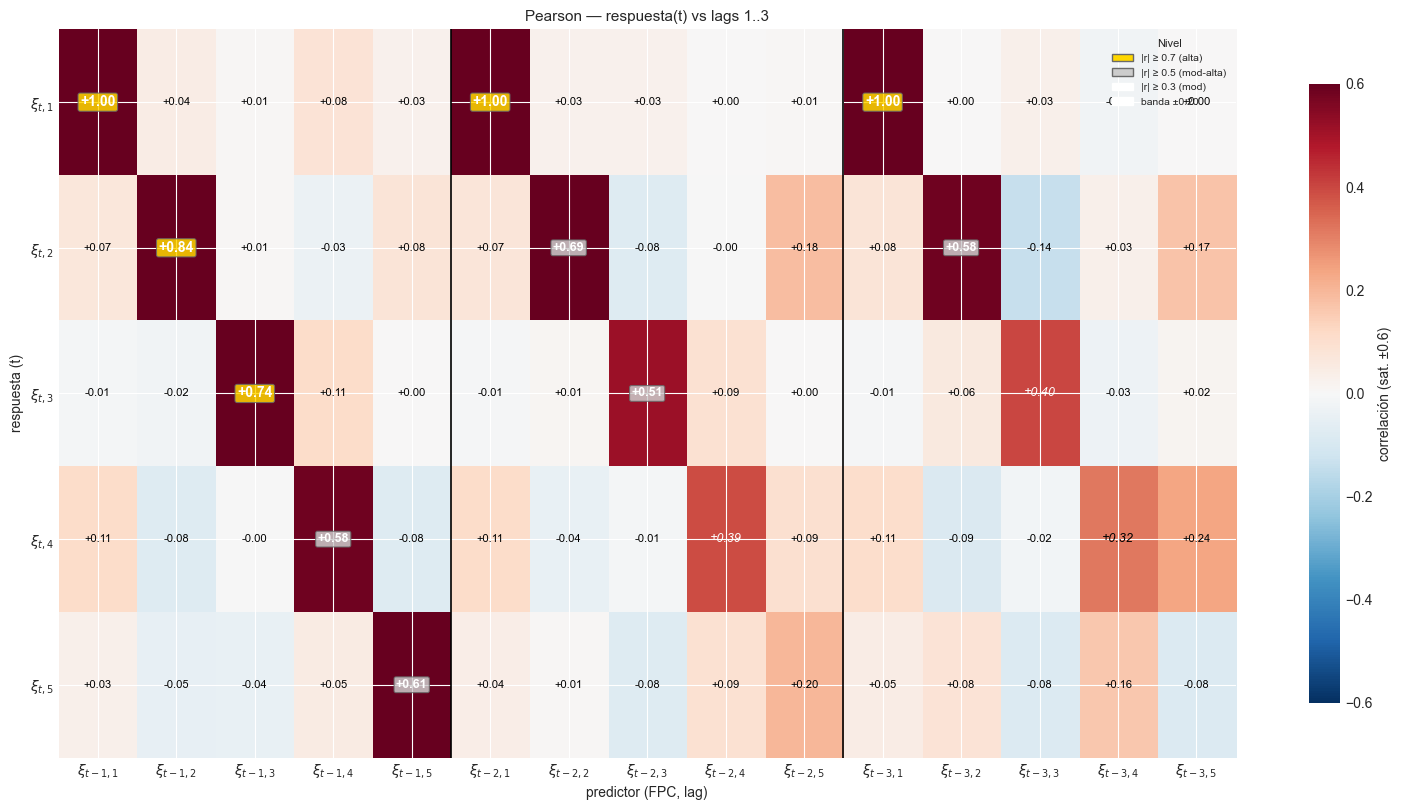

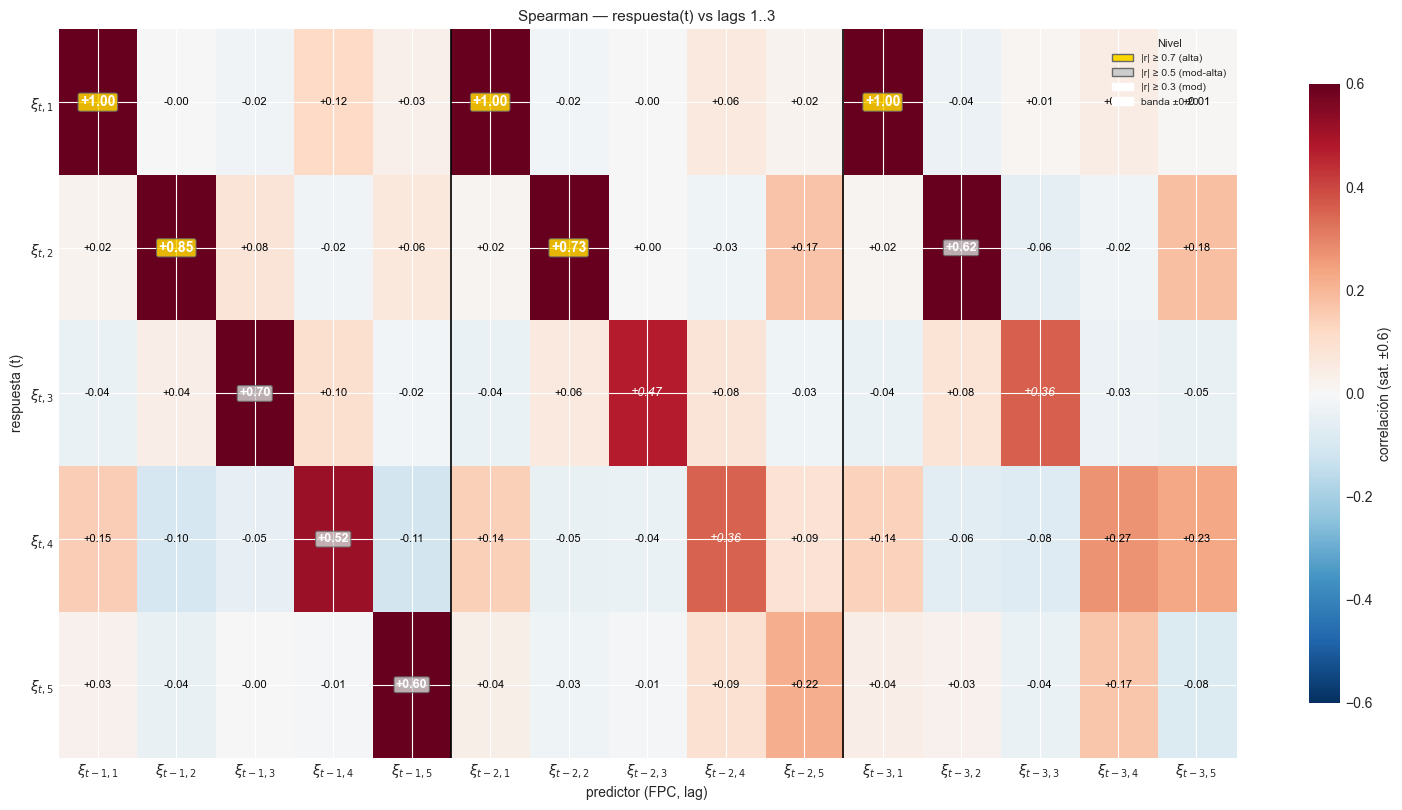

In [49]:
T_theta = SCORES.shape[0]
K_total = SCORES.shape[1]                                # nº de FPC disponibles (M)

# Lags de Diagnostico
N_LAGS_MAX = 3
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

# ── Matrices de correlación: respuesta (t) × predictor (FPC j, lag ℓ) ────────
n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES[N_LAGS_MAX:, :]                         # respuesta en t (alineada)

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES[N_LAGS_MAX - lag : T_theta - lag, :]   # predictores en t-lag
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))                      # banda de significancia (referencia)

# ── Estilo por |r| ────────────────────────────────────────────────────────────
def _text_style(val):
    a = abs(val)
    if   a >= 0.7: return 10, "bold",   "normal", "gold"      # alta
    elif a >= 0.5: return 9,  "bold",   "normal", "#cccccc"   # mod-alta
    elif a >= 0.3: return 9,  "normal", "italic", None        # moderada
    else:          return 8,  "normal", "normal", None        # baja

VCLIP = 0.6
norm  = mcolors.Normalize(vmin=-VCLIP, vmax=VCLIP, clip=True)

def _draw_heatmap(matrix, title, fname):
    fig, ax = plt.subplots(figsize=(0.9 * n_cov + 2, 1.4 * K_total + 1.2))
    im = ax.imshow(matrix, cmap="RdBu_r", norm=norm, aspect="auto")
    ax.set_xticks(range(n_cov)); ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(K_total)); ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_xlabel("predictor (FPC, lag)"); ax.set_ylabel("respuesta (t)")
    ax.set_title(title, fontsize=11)
    for lag in range(1, N_LAGS_MAX):                     # separadores entre bloques de lag
        ax.axvline(lag * K_total - 0.5, color="black", lw=1.2)
    for i in range(K_total):
        for j in range(n_cov):
            val = matrix[i, j]; fs, fw, fst, box = _text_style(val)
            bbox = (dict(boxstyle="round,pad=0.15", facecolor=box,
                         edgecolor="dimgray", alpha=0.85, lw=0.8) if box else None)
            ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                    color=("white" if abs(val) > 0.35 else "black"),
                    fontsize=fs, fontweight=fw, fontstyle=fst, bbox=bbox)
    legend_elements = [
        mpatches.Patch(facecolor="gold",    edgecolor="dimgray", label="|r| ≥ 0.7 (alta)"),
        mpatches.Patch(facecolor="#cccccc", edgecolor="dimgray", label="|r| ≥ 0.5 (mod-alta)"),
        mpatches.Patch(facecolor="white",   edgecolor="white",   label="|r| ≥ 0.3 (mod)"),
        mpatches.Patch(facecolor="white",   edgecolor="white",   label=f"banda ±{band:.2f}"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=7.5,
              framealpha=0.9, title="Nivel", title_fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.85, label=f"correlación (sat. ±{VCLIP})")
    fig.tight_layout()
    fig.savefig(PATHS["out"] / fname, dpi=110, bbox_inches="tight")
    plt.show()

_draw_heatmap(corr_pearson,  f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",  "12a_rezagos_pearson.png")
_draw_heatmap(corr_spearman, f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}", "12b_rezagos_spearman.png")


## 4.2 Selecion de lags y DATSET final 

In [50]:
N_LAGS  = 2
T_theta = SCORES.shape[0]
K_total = SCORES.shape[1]   # nº de FPC disponibles (M)
T_eff   = T_theta - N_LAGS
COMPONENT_IDX = list(range(K_total)) 

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T_theta             : {T_theta}")
print(f"N_LAGS              : {N_LAGS}")
print(f"T_eff               : {T_eff}")

K_total disponibles : 5  (índices 0 … 4)
T_theta             : 100
N_LAGS              : 2
T_eff               : 98


In [51]:
# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

K_total disponibles : 5
Componentes usados  : 5  →  índices [0, 1, 2, 3, 4]
Orden AR (N_LAGS)   : 2

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0           fpc_1
         1           1           fpc_2
         2           2           fpc_3
         3           3           fpc_4
         4           4           fpc_5


In [52]:
# ── Construcción de DataFrames AR(p) ─────────────────────────────────────────
SCORES_sel = SCORES[:, COMPONENT_IDX]   # (T, n_components) — scores de FPCA

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

dfs = {}
for k in range(n_components):
    y_col  = SCORES_sel[N_LAGS:, k]
    X_cols = np.hstack([
        SCORES_sel[N_LAGS - lag: T_theta - lag, :]
        for lag in range(1, N_LAGS + 1)
    ])
    resp_name = f"fpc_{COMPONENT_IDX[k] + 1}"
    dfs[k] = pd.DataFrame(
        np.column_stack([y_col, X_cols]),
        columns=[resp_name] + cov_names,
    )

manifest = {
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "datasets":      {},
}
for k in range(n_components):
    fname = f"dataset_fpc_{COMPONENT_IDX[k] + 1}.csv"
    dfs[k].to_csv(PATHS["functional"] / fname, index=False)
    manifest["datasets"][fname] = {
        "response": f"fpc_{COMPONENT_IDX[k] + 1}",
        "shape":    list(dfs[k].shape),
    }
    print(f"  guardado {fname}  resp='fpc_{COMPONENT_IDX[k] + 1}'  shape={dfs[k].shape}")

with open(PATHS["functional"] / "datasets_manifest.json", "w", encoding="utf-8") as _f:
    json.dump(manifest, _f, indent=2, ensure_ascii=False)
print(f"[functional] {n_components} datasets + datasets_manifest.json → {PATHS['functional']}")

  guardado dataset_fpc_1.csv  resp='fpc_1'  shape=(98, 11)
  guardado dataset_fpc_2.csv  resp='fpc_2'  shape=(98, 11)
  guardado dataset_fpc_3.csv  resp='fpc_3'  shape=(98, 11)
  guardado dataset_fpc_4.csv  resp='fpc_4'  shape=(98, 11)
  guardado dataset_fpc_5.csv  resp='fpc_5'  shape=(98, 11)
[functional] 5 datasets + datasets_manifest.json → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\functional\01_01_modelo_2


# 5. PASO 5 ES EL NEXO entre matlab y python

In [53]:
MCMC_CONFIG = {"nsim": 1000, "burn": 500, "N": 15, "M": 50}
N_CHAINS    = 1
CHAIN_SEEDS = [SEED + c * 100 for c in range(N_CHAINS)]
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  |  CHAIN_SEEDS: {CHAIN_SEEDS}")

MCMC_CONFIG : {'nsim': 1000, 'burn': 500, 'N': 15, 'M': 50}
N_CHAINS    : 1  |  CHAIN_SEEDS: [4123]


In [54]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  5 componentes × 10 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (fpc_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  fpc_2_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_4_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_5_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_1_lag2                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_2_lag2                 cross_lag       1

In [55]:
import numpy as np
from scipy.io import loadmat

def load_trace_mat(path):
    m = loadmat(path)
    keys = ["betajhout","beta0hout","tauhout","alphahout","psijhout","Gammajhout",
            "gammajhout","pijout","wjout","osumout","inEout"]          # 2D / 3D
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in keys}
    for k in ["muout","N1out","Nout"]:                                  # (nsim,1) -> (nsim,)
        traces[k] = np.asarray(m[k], dtype=np.float64).ravel()
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feature_names = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feature_names

traces, burn, feature_names = load_trace_mat("psbp_trace_fpc_1.mat")


# 6. Diagnósticos de convergencia MCMC

| Estadístico | Referencia | Lectura |
|---|---|---|
| ACF(lag) | autocorrelación residual | cerca de 0 ⇒ buena mezcla |
| ESS | Geyer (1992) | ESS ≳ 400 ideal |
| Geweke z | test z entre segmentos | \|z\| < 2 ⇒ no rechazo |
| Gelman-Rubin R̂ | Brooks-Gelman (1998) | R̂ < 1.1 ⇒ convergencia |


## 6.1 Componentes globales

In [ ]:
for k in range(n_components):
    fig = plot_global_components(
        models_chains, k, BURN, N_CHAINS,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out"] / f"10_global_comp_k{k+1}.png"),
    )
    plt.show()

In [ ]:
for k in range(n_components):
    fig = plot_active_clusters(
        models_chains, k, BURN, N_CHAINS,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out"] / f"11_clusters_activos_k{k+1}.png"),
    )
    plt.show()

## 6.2 Trazas + ACF de β_j y p_j

In [ ]:
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig  = plot_traces_bj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"12_trazas_bj_k{k+1}.png"),
    )
    plt.show()

In [ ]:
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig  = plot_traces_pj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"13_trazas_pj_k{k+1}.png"),
    )
    plt.show()

## 6.3 Convergencia completa (traza | ACF | posterior + métricas)

In [ ]:
all_diag_bj = {}
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_bj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"14_convergencia_bj_k{k+1}.png"),
    )
    all_diag_bj[k] = diag
    plt.show()

In [ ]:
all_diag_pj = {}
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_pj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"15_convergencia_pj_k{k+1}.png"),
    )
    all_diag_pj[k] = diag
    plt.show()

In [ ]:
# ── Tabla resumen de convergencia ────────────────────────────────────────────
diag_records = []
for k in range(n_components):
    for rec in all_diag_bj[k]:
        diag_records.append({"componente": k+1, "param": "beta_j", **rec})
    for rec in all_diag_pj[k]:
        diag_records.append({"componente": k+1, "param": "p_j",    **rec})

diag_df = pd.DataFrame(diag_records)
display(
    diag_df.style
    .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
             "geweke_max": "{:+.2f}", "rhat": "{:.3f}"})
    .background_gradient(subset=["rhat"],    cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
    .background_gradient(subset=["ess_min"], cmap="RdYlGn",   vmin=0,   vmax=500)
    .map(lambda v: "font-weight:bold;color:#c0392b" if v is False else "",
         subset=["converge"])
    .set_caption("Diagnósticos MCMC por variable")
)

# 7. Evaluación predictiva

In [ ]:
eval_results = {}
for k in range(n_components):
    m     = models_chains[k][0]
    y_obs = dfs[k].iloc[:, 0].to_numpy()
    y_hat = m.predict(dfs[k])
    incl  = m.inclusion_probs(as_series=True)
    eval_results[k] = {
        "rmse":       m.rmse(dfs[k]),
        "y_hat":      y_hat,
        "y_obs":      y_obs,
        "incl_vec":   incl.values,
        "incl_named": incl,
    }
    print(f"Componente {k+1}:  inRMSE = {eval_results[k]['rmse']:.6f}")
    for name, val in incl.items():
        print(f"    P(γ=1 | {name:<22}) = {val:.4f}{'  *' if val > 0.5 else ''}")

## 7.1 Scatter θ_obs vs θ_hat

In [ ]:
fig = plot_scatter_theta(
    eval_results,
    n_components = n_components,
    save_path    = str(PATHS["out"] / "16_scatter_theta.png"),
)
plt.show()

## 7.2 Comparativa de reconstrucción funcional (snapshots)

In [ ]:
# ── Reconstrucción funcional vía FPCA (inversa: X̂ = μ + Σ ξ̂_m ψ_m) ──────────
# Las predicciones AR(1) cubren t = N_LAGS … T-1  (T_eff filas). Reconstruimos
# en la grilla con las autofunciones de FPCA, NO con la base B-spline.
SCORES_true_al   = SCORES[N_LAGS:]                       # (T_eff, M) scores verdaderos alineados
SCORES_pred_full = SCORES_true_al.copy()
for k, idx in enumerate(COMPONENT_IDX):                  # sobre-escribe SOLO los FPC modelados
    SCORES_pred_full[:, idx] = eval_results[k]["y_hat"]  # (los no modelados usan su score real)

X_true_al = X[N_LAGS:]                                    # empírica (estandarizada)
X_repr_al = FPCA["reconstruct"](SCORES_true_al)          # mejor representación con M FPC
X_pred_al = FPCA["reconstruct"](SCORES_pred_full)        # predicción PSBP reconstruida

def _rmse_curves(A, B):
    return float(np.sqrt(np.mean((np.asarray(A) - np.asarray(B)) ** 2)))

recon_metrics = {
    "rmse_pred_vs_true": _rmse_curves(X_pred_al, X_true_al),
    "rmse_repr_vs_true": _rmse_curves(X_repr_al, X_true_al),
    "M_fpca": int(FPCA["M"]),
}

def plot_recon_snapshots(t_idx, title, save_path):
    t_idx = [t for t in t_idx if 0 <= t < X_true_al.shape[0]]
    n = len(t_idx); ncol = min(n, 5); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.0 * nrow), squeeze=False)
    flat = axes.ravel()
    for ax, t in zip(flat, t_idx):
        ax.plot(domain.grid, X_true_al[t], color="black",     lw=1.6, label="empírica")
        ax.plot(domain.grid, X_repr_al[t], color="tab:green", lw=1.2, ls="--", label=f"FPCA (M={FPCA['M']})")
        ax.plot(domain.grid, X_pred_al[t], color="crimson",   lw=1.2, label="PSBP pred.")
        ax.set_title(f"t = {t + N_LAGS}"); ax.set_xlabel("s")
    for ax in flat[len(t_idx):]:
        ax.axis("off")
    flat[0].legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(save_path, dpi=110, bbox_inches="tight")
    return fig

fig = plot_recon_snapshots(
    [0, 1, T_eff // 2, T_eff - 2, T_eff - 1],
    f"Reconstrucción funcional FPCA — snapshots  (inRMSE pred = {recon_metrics['rmse_pred_vs_true']:.4f})",
    str(PATHS["out"] / "17_recon_funcional_snapshots.png"),
)
plt.show()
print(recon_metrics)

In [ ]:
# ── Snapshots adicionales ─────────────────────────────────────────────────────
fig = plot_recon_snapshots(
    [5, 15, 30, 50, 80],
    "Reconstrucción funcional FPCA — ejemplos adicionales",
    str(PATHS["out"] / "18_recon_funcional_extra.png"),
)
plt.show()

## 7.3 Comparativa de serie de tiempo completa (todo T)

In [ ]:
# ── X_pred_repr (todo T_eff) — ya reconstruido en 7.2 vía FPCA ───────────────
X_pred_repr = X_pred_al                                  # (T_eff, G)
print(f"X_pred_repr shape: {X_pred_repr.shape}  (T_eff={T_eff}, G={G})")

# ── Persistencia de datos · predicción → data/.../processed/predict ──────────
np.savetxt(PATHS["predict"] / "scores_pred.csv",       SCORES_pred_full, delimiter=",")  # scores predichos (T_eff×M)
np.savetxt(PATHS["predict"] / "curves_pred.csv",       X_pred_al,        delimiter=",")  # curvas reconstruidas (T_eff×G)
np.savetxt(PATHS["predict"] / "curves_true_align.csv", X_true_al,        delimiter=",")  # empíricas alineadas (T_eff×G)
print(f"[predict] scores_pred {SCORES_pred_full.shape} · curves_pred {X_pred_al.shape}  →  {PATHS['predict']}")

In [ ]:
# ── Comparativa STF completa: empírica vs PSBP (reconstruido por FPCA) ────────
sep_every = 5
sep = 1.2 * float(np.max(np.abs(X_true_al))) / sep_every
fig, ax = plt.subplots(figsize=(12, 6))
for t in range(X_true_al.shape[0]):
    off = t * sep
    ax.plot(domain.grid, X_true_al[t] + off, color="black",   lw=0.7, alpha=0.7)
    ax.plot(domain.grid, X_pred_al[t] + off, color="crimson", lw=0.7, alpha=0.7)
ax.plot([], [], color="black",   label="empírica")
ax.plot([], [], color="crimson", label="PSBP pred. (FPCA)")
ax.set(title=f"Comparativa STF — empírica vs PSBP  (FPCA, M={FPCA['M']}, T_eff={T_eff})",
       xlabel="s", ylabel="curvas desplazadas en t")
ax.legend(loc="upper right"); fig.tight_layout()
fig.savefig(PATHS["out"] / "19_fts_comparativa_completa.png", dpi=110, bbox_inches="tight")
plt.show()

ts_metrics = {
    "rmse_global":   _rmse_curves(X_pred_al, X_true_al),
    "rmse_per_time": [_rmse_curves(X_pred_al[t], X_true_al[t]) for t in range(X_true_al.shape[0])],
}
print(f"RMSE global (todo T_eff): {ts_metrics['rmse_global']:.6f}")

# 8. Persistencia de resultados

Guardamos dos archivos JSON en `reports/simulaciones/metrics/`:

| Archivo | Contenido |
|---|---|
| `{EXPERIMENT_ID}_metrics.json` | Diagnósticos MCMC + RMSE por componente + métricas de reconstrucción |
| `{EXPERIMENT_ID}_config.json`  | Parámetros del experimento para reproducibilidad |

Las figuras ya se guardaron durante el notebook vía `save_path`.


In [ ]:
# ── Serializador robusto de tipos numpy ───────────────────────────────────────
def _to_python(obj):
    """
    Convierte recursivamente tipos numpy / Python no serializables a tipos
    nativos compatibles con json.dump.

    Cubre:
        np.integer, np.floating, np.bool_  → int, float, bool
        np.ndarray                          → list (recursivo)
        dict, list, tuple                   → mismo tipo, recursivo
        bool nativo                         → bool  (debe ir antes que int)
        Cualquier otro                      → pass-through
    """
    if isinstance(obj, bool):            return obj               # antes de int
    if isinstance(obj, np.bool_):        return bool(obj)
    if isinstance(obj, np.integer):      return int(obj)
    if isinstance(obj, np.floating):     return float(obj)
    if isinstance(obj, np.ndarray):      return [_to_python(v) for v in obj.tolist()]
    if isinstance(obj, dict):            return {k: _to_python(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):   return [_to_python(v) for v in obj]
    return obj

print("_to_python listo.")

In [ ]:
# ── Construir payload de métricas ────────────────────────────────────────────
metrics_out = _to_python({
    "experiment_id":  EXPERIMENT_ID,
    "timestamp":      TIMESTAMP,
    "n_components":   n_components,
    "n_lags":         N_LAGS,
    "mcmc_config":    MCMC_CONFIG,
    "n_chains":       N_CHAINS,
    "burn":           BURN,
    "fit_times_s":    fit_times,
    "convergence_bj": {k: all_diag_bj[k] for k in all_diag_bj},
    "convergence_pj": {k: all_diag_pj[k] for k in all_diag_pj},
    "rmse_per_component": {
        k: eval_results[k]["rmse"] for k in range(n_components)
    },
    "recon_metrics":  recon_metrics,
    "ts_metrics":     ts_metrics,
    "inclusion_probs": {
        k: dict(eval_results[k]["incl_named"]) for k in range(n_components)
    },
})

metrics_path = PATHS["out"] / f"{EXPERIMENT_ID}_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)
print(f"Métricas  → {metrics_path}  ({metrics_path.stat().st_size / 1024:.1f} KB)")

In [ ]:
# ── Construir payload de configuración ───────────────────────────────────────
config_out = _to_python({
    "experiment_id":  EXPERIMENT_ID,
    "timestamp":      TIMESTAMP,
    "seed":           SEED,
    "far_params":     FAR_PARAMS,
    "standarize":     STANDARIZE_CONFIG,
    "bspline":        {"n_basis": nb_best, "order": ord_best},
    "fpca":           {"M": int(M_fpca), "var_target": VAR_TARGET, "var_explained": float(var_cum[M_fpca - 1])},
    "mcmc":           MCMC_CONFIG,
    "n_chains":       N_CHAINS,
    "chain_seeds":    CHAIN_SEEDS,
    "n_lags":         N_LAGS,
    "n_components":   n_components,
})

config_path = PATHS["out"] / f"{EXPERIMENT_ID}_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_out, f, indent=2, ensure_ascii=False)
print(f"Config    → {config_path}  ({config_path.stat().st_size / 1024:.1f} KB)")

In [ ]:
# ── Verificación de integridad: re-leer y parsear los dos JSON ────────────────
for path in [metrics_path, config_path]:
    with open(path, "r", encoding="utf-8") as f:
        loaded = json.load(f)
    print(f"OK  {path.name}  ({len(loaded)} claves raíz)")

In [ ]:
# ── Resumen final ─────────────────────────────────────────────────────────────
figures_saved = sorted(PATHS["out"].glob("*.png"))
metrics_saved = sorted(PATHS["out"].glob("*.json"))

print("\n" + "="*65)
print(f"  Experimento  : {EXPERIMENT_ID}")
print(f"  Componentes  : {n_components}  |  N_LAGS: {N_LAGS}")
print(f"  Cadenas      : {N_CHAINS}       |  Burn-in: {BURN}")
print("─"*65)
print("  RMSE in-sample por componente:")
for k in range(n_components):
    print(f"    k={k+1}  →  {eval_results[k]['rmse']:.6f}")
print("─"*65)
print(f"  RMSE repr  (B-spline) : {recon_metrics.get('rmse_repr',  float('nan')):.6f}")
print(f"  RMSE model (PSBP→func): {recon_metrics.get('rmse_model', float('nan')):.6f}")
print(f"  RMSE total            : {recon_metrics.get('rmse_total', float('nan')):.6f}")
print("─"*65)
n_conv = sum(
    1 for k in range(n_components)
    for rec in all_diag_bj[k] + all_diag_pj[k]
    if rec.get("converge", False)
)
n_total = sum(len(all_diag_bj[k]) + len(all_diag_pj[k]) for k in range(n_components))
print(f"  Convergencia : {n_conv}/{n_total} parámetros (R̂<1.1 & ESS>100 & |G|<2)")
print("─"*65)
print(f"  Figuras guardadas : {len(figures_saved)}  →  {PATHS['out']}")
print(f"  JSONs guardados   : {len(metrics_saved)}  →  {PATHS['out']}")
print("="*65)